In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
!pip install xgboost
import xgboost

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score , precision_score ,recall_score , f1_score
from sklearn.metrics import confusion_matrix , classification_report
import sklearn.model_selection as skm

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import (DecisionTreeClassifier as DTC, plot_tree, export_text)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA\
,QuadraticDiscriminantAnalysis as QDA
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')
!pip install shap
import shap

import tensorflow as tf
from tensorflow import keras
!pip install scikeras
from scikeras.wrappers import KerasClassifier

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

In [ ]:
adult = fetch_ucirepo(id=2)
X = adult.data.features
y = adult.data.targets

In [ ]:
data=pd.concat([y,X],axis=1)
data['income'] = data['income'].str.replace('.', '', regex=False)
data.head()

,income,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,<=50K,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,<=50K,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,<=50K,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,<=50K,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,<=50K,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [ ]:
data.dropna(inplace=True)
data.shape

(47621, 15)

In [ ]:
data = data.sample(n=10000, random_state=42)

data['education'] = data['education'].replace(['11th', '10th', '9th', '12th'], 'HS-no_grad')
data['education'] = data['education'].replace(['Preschool','1st-4th', '5th-6th', '7th-8th'], 'Grade_school')
data['workclass'] = data['workclass'].replace(['Local-gov', 'State-gov', 'Federal-gov'], 'Gov-jobs')
data['workclass'] = data['workclass'].replace(['Self-emp-not-inc', 'Self-emp-inc'], 'Self-employed')
data['marital-status']=data['marital-status'].replace(['Divorced', 'Separated'], 'No-longer-married')
data = data.replace('?', 'Undisclosed')
data['native-country'] = data['native-country'].apply(lambda x: x if x in ['United-States', 'Mexico'] else 'Other-country')
data.head()

,income,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
1536,<=50K,34,Private,122116,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States
20190,<=50K,36,Gov-jobs,223020,Some-college,10,No-longer-married,Other-service,Unmarried,Black,Female,0,0,20,United-States
47437,<=50K,59,Self-employed,165867,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,25,United-States
10192,>50K,59,Private,453067,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,36,United-States
38494,>50K,36,Private,49657,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States


In [ ]:
obj_data=data.loc[:,['sex','workclass','education','marital-status','occupation','relationship','race','native-country']]
data.drop(columns=['sex','workclass','education','marital-status','occupation','relationship','race','native-country'],inplace=True)

obj_data=pd.get_dummies(obj_data,prefix='fet')
obj_data=obj_data.replace({False:0,True:1})

encoder = LabelEncoder()
for col in data.select_dtypes("object"):
    data[col] =encoder.fit_transform(data[[col]])

X=data.drop(columns=['income'])
X=pd.concat([X,obj_data],axis=1)
X = X.astype(float)
y=data['income']
X.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,fet_Female,fet_Male,fet_Gov-jobs,fet_Private,...,fet_Unmarried,fet_Wife,fet_Amer-Indian-Eskimo,fet_Asian-Pac-Islander,fet_Black,fet_Other,fet_White,fet_Mexico,fet_Other-country,fet_United-States
1536,34.0,122116.0,10.0,0.0,0.0,40.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
20190,36.0,223020.0,10.0,0.0,0.0,20.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
47437,59.0,165867.0,13.0,0.0,0.0,25.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
10192,59.0,453067.0,10.0,0.0,0.0,36.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
38494,36.0,49657.0,13.0,0.0,0.0,50.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


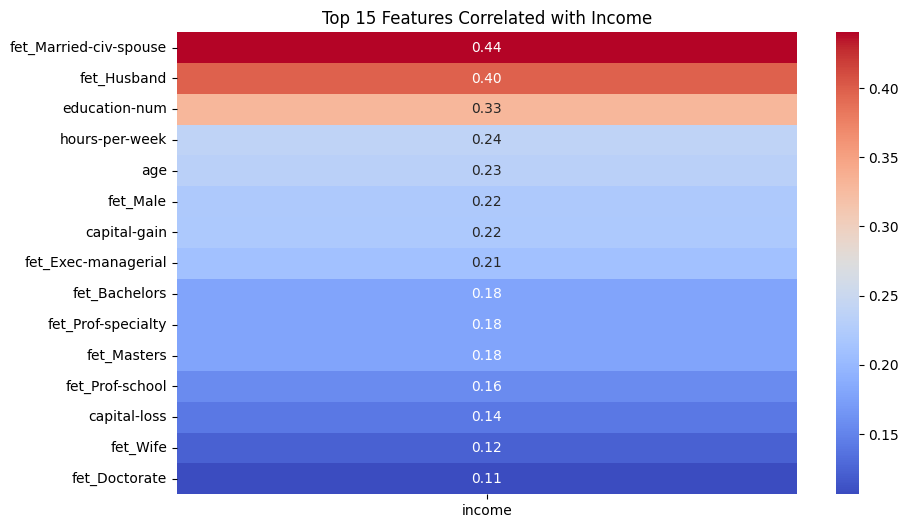

In [ ]:
sns.set_palette("pastel")

plt.figure(figsize=(10,6))
data2=pd.concat([y,X],axis=1)

correlations = data2.corr()['income'].sort_values(ascending=False)

# Select top 15 features
top_15_features = correlations[1:16]  # Exclude 'income' itself

# Create a DataFrame for the heatmap
top_15_corr_df = pd.DataFrame(top_15_features)
sns.heatmap(top_15_corr_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 15 Features Correlated with Income')
plt.show()

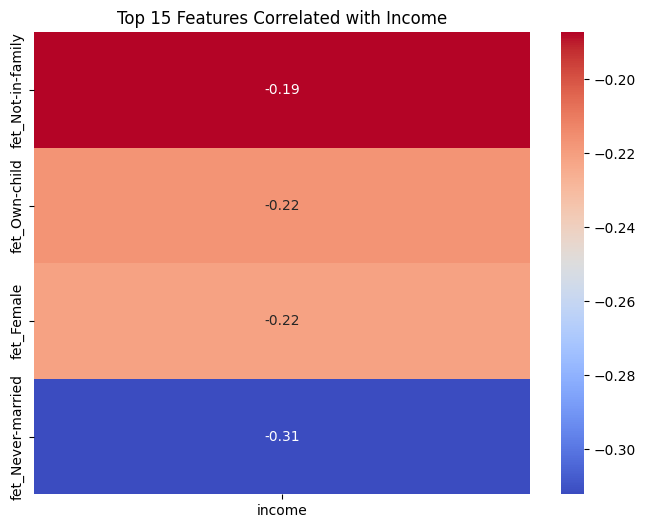

In [ ]:
plt.figure(figsize=(8,6))
top_15_corr_df = pd.DataFrame(correlations[55:59])
sns.heatmap(top_15_corr_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 15 Features Correlated with Income')
plt.show()

In [ ]:
scaler = StandardScaler()
for col in X.columns:
    X[col] = scaler.fit_transform(X[[col]])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=162)
X_train.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,fet_Female,fet_Male,fet_Gov-jobs,fet_Private,...,fet_Unmarried,fet_Wife,fet_Amer-Indian-Eskimo,fet_Asian-Pac-Islander,fet_Black,fet_Other,fet_White,fet_Mexico,fet_Other-country,fet_United-States
40198,-1.315462,2.579025,-0.435755,-0.146619,-0.210876,-0.062394,1.422634,-1.422634,-0.399106,0.648736,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,-0.284337,0.323994
45664,1.350715,0.020306,-0.435755,-0.146619,-0.210876,-0.062394,-0.702921,0.702921,-0.399106,0.648736,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,-0.284337,0.323994
3918,0.610110,-1.061531,-0.435755,-0.146619,-0.210876,0.763030,-0.702921,0.702921,-0.399106,0.648736,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,-0.284337,0.323994
15653,-0.204555,-0.372319,-0.435755,-0.146619,-0.210876,-0.062394,1.422634,-1.422634,-0.399106,0.648736,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,-0.284337,0.323994
18365,-0.130495,0.064007,-0.046688,0.174551,-0.210876,-0.062394,1.422634,-1.422634,-0.399106,0.648736,...,-0.351023,-0.217072,-0.102515,-0.167845,-0.320022,-0.086343,0.400284,-0.143584,3.516957,-3.086473


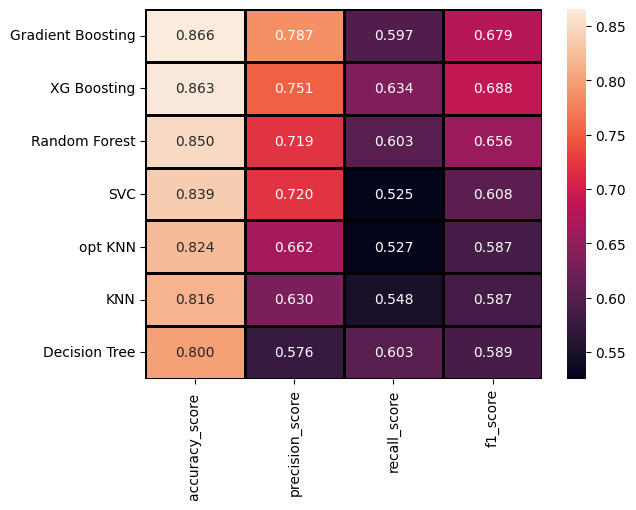

In [ ]:
model_dic={
    'Random Forest':RandomForestClassifier(),
    "Decision Tree":DTC(),
    'Gradient Boosting':GradientBoostingClassifier(),
    'XG Boosting':XGBClassifier(),
    "KNN":KNeighborsClassifier(),
    "opt KNN": KNeighborsClassifier(n_neighbors=15,weights='uniform',metric='manhattan',leaf_size=17,algorithm='ball_tree',p=2),
    "SVC":SVC(kernel='linear')
}

acc_dic={}

for (i, model) in model_dic.items():
    if i == 'XG Boosting':
        model.fit(X_train.to_numpy(), y_train)  # Convert to NumPy array
        y_pred = model.predict(X_test.to_numpy())  # Convert to NumPy array
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        if i in ['Opt. Nueral Network', 'Nueral Network']:
            y_pred = (y_pred > 0.5).astype(int)

    acc_dic[i]={'accuracy_score ':accuracy_score(y_test,y_pred),
                "precision_score"  :precision_score(y_test,y_pred),
                "recall_score"  :recall_score(y_test,y_pred),
                "f1_score"  :f1_score(y_test,y_pred),}

acc_dic=pd.DataFrame(acc_dic)
acc_dic_transposed = acc_dic.T
acc_dic_sorted = acc_dic_transposed.sort_values(by=['accuracy_score '],ascending=False)

sns.heatmap(acc_dic_sorted, annot=True, linecolor="black", linewidths=1, fmt=".3f")
plt.show()

The optimal number of neighbors is 15 with an average training accuracy of 0.8245


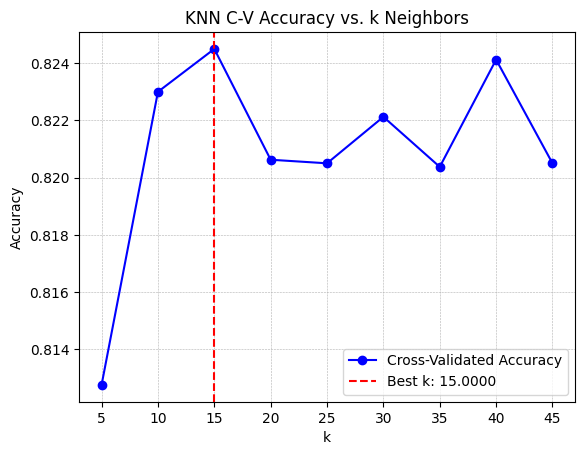

In [ ]:
k_values = range(5,50,5)
cv_scores = []

# Performing 10-fold cross-validation for each k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of neighbors is {optimal_k} with an average training accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b', label='Cross-Validated Accuracy')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('KNN C-V Accuracy vs. k Neighbors')

plt.axvline(optimal_k, color='r', linestyle='--', label=f'Best k: {optimal_k:.4f}')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.4)
plt.show()

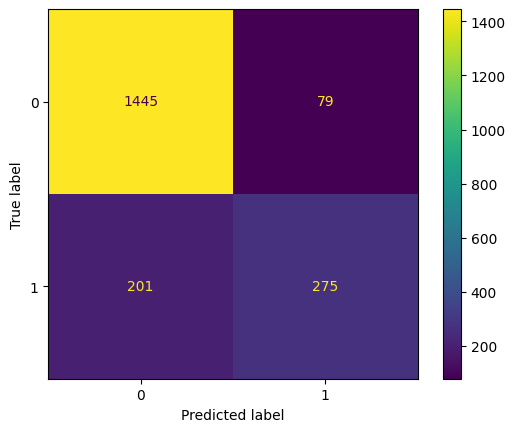

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


knn_model = RandomForestClassifier(n_estimators=300,min_samples_split=20,min_samples_leaf=4,max_depth=25)
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_model.classes_)
disp.plot()
plt.show()

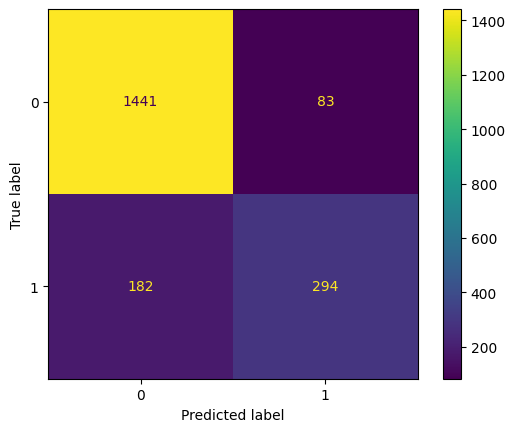

In [ ]:
knn_model = XGBClassifier(n_estimators=90,tree_method='auto',subsample=1,reg_lambda=0.05,reg_alpha=0.1,min_child_weight=3,max_depth=3,learning_rate=0.3,gamma=0.005,colsample_bytree=0.4)
knn_model.fit(X_train.to_numpy(), y_train)
y_pred = knn_model.predict(X_test.to_numpy())


cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_model.classes_)
disp.plot()
plt.show()

The optimal number of estimators is 300 with an average training accuracy of 0.8440


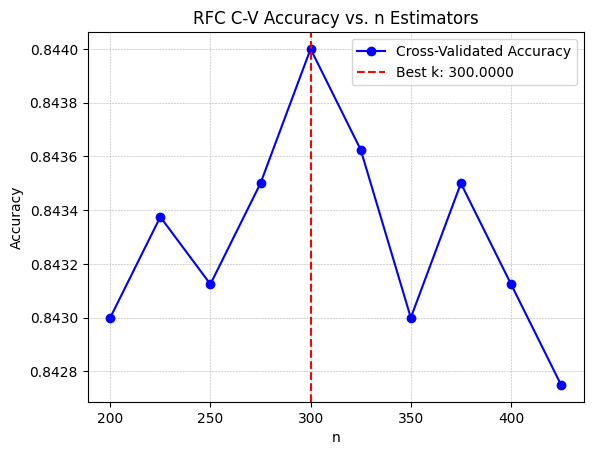

In [ ]:
k_values = range(200,450, 25)
cv_scores = []

for k in k_values:
    rfc = RandomForestClassifier(n_estimators=k,random_state=101)
    scores = cross_val_score(rfc, X_train, y_train, cv=3, scoring='accuracy',n_jobs=-1)
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of estimators is {optimal_k} with an average training accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b', label='Cross-Validated Accuracy')
plt.xlabel('n')
plt.ylabel('Accuracy')
plt.title('RFC C-V Accuracy vs. n Estimators')

plt.axvline(optimal_k, color='r', linestyle='--', label=f'Best k: {optimal_k:.4f}')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.4)
plt.show()

The optimal number of estimators is 3 with an average accuracy of 0.8607


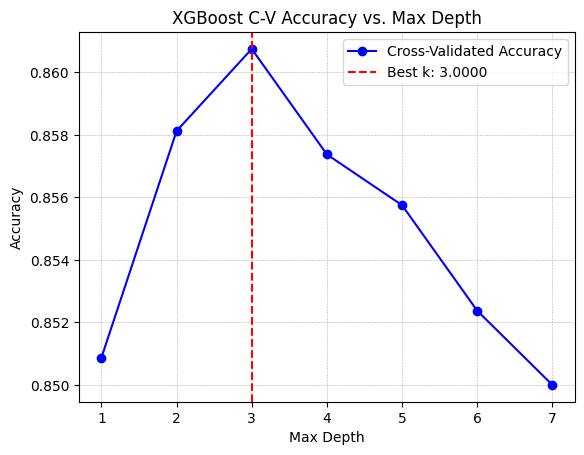

In [ ]:
k_values = range(1, 8)
cv_scores = []

for k in k_values:
    xg = XGBClassifier(max_depth=k)
    # Convert X_train and y_train to NumPy arrays before passing to cross_val_score
    scores = cross_val_score(xg, X_train.to_numpy(), y_train.to_numpy(), cv=3, scoring='accuracy', n_jobs=-1)
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of estimators is {optimal_k} with an average accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b', label='Cross-Validated Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('XGBoost C-V Accuracy vs. Max Depth')
plt.axvline(optimal_k, color='r', linestyle='--', label=f'Best k: {optimal_k:.4f}')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.4)
plt.show()

The optimal number of estimators is 90 with an average accuracy of 0.8610


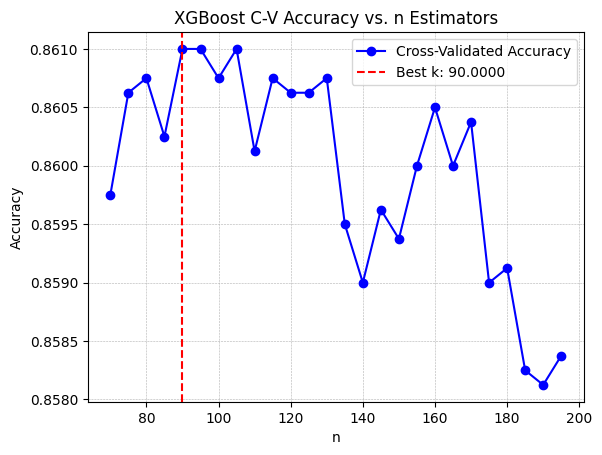

In [ ]:
k_values = range(70,200,5)
cv_scores = []

for k in k_values:
    xg = XGBClassifier(n_estimators=k,max_depth=3)
    scores = cross_val_score(xg, X_train.to_numpy(), y_train.to_numpy(), cv=3, scoring='accuracy',n_jobs=-1)
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of estimators is {optimal_k} with an average accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b', label='Cross-Validated Accuracy')
plt.xlabel('n')
plt.ylabel('Accuracy')
plt.title('XGBoost C-V Accuracy vs. n Estimators')
plt.axvline(optimal_k, color='r', linestyle='--', label=f'Best k: {optimal_k:.4f}')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.4)
plt.show()

The optimal number of estimators is 300 with an average accuracy of 0.8584


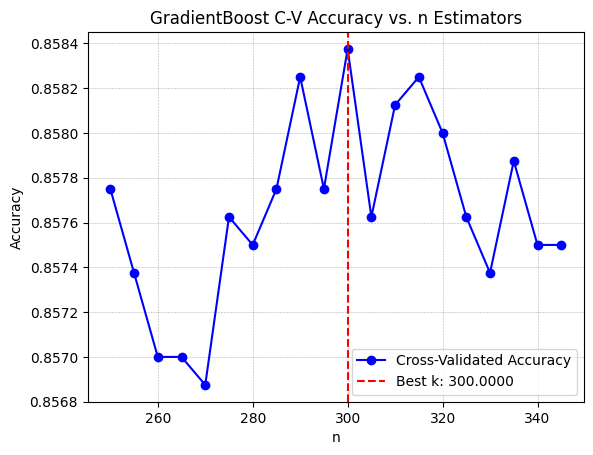

In [ ]:
k_values = range(250,350,5)
cv_scores = []

for k in k_values:
    gd = GradientBoostingClassifier(n_estimators=k,random_state=101)
    scores = cross_val_score(gd, X_train, y_train, cv=5, scoring='accuracy',n_jobs=-1)
    cv_scores.append(scores.mean())

optimal_k = k_values[np.argmax(cv_scores)]
print(f"The optimal number of estimators is {optimal_k} with an average accuracy of {max(cv_scores):.4f}")

plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b', label='Cross-Validated Accuracy')
plt.xlabel('n')
plt.ylabel('Accuracy')
plt.title('GradientBoost C-V Accuracy vs. n Estimators')
plt.axvline(optimal_k, color='r', linestyle='--', label=f'Best k: {optimal_k:.4f}')
plt.legend()
plt.grid(True, which="both", linestyle='--', linewidth=0.4)
plt.show()

In [ ]:
clf=DTC(criterion='entropy',random_state=101)
clf.fit(X_train,y_train)
accuracy_score(y_test,clf.predict(X_test))  #test accuracy with no pruning

0.8095

In [ ]:
ccp_path = clf.cost_complexity_pruning_path(X_train, y_train)
kfold=skm.KFold(5,random_state=101,shuffle=True)
grid=skm.GridSearchCV(clf, {'ccp_alpha':ccp_path.ccp_alphas}, refit=True, cv=kfold, scoring='accuracy')
grid.fit(X_train,y_train)
grid.best_score_

0.843125

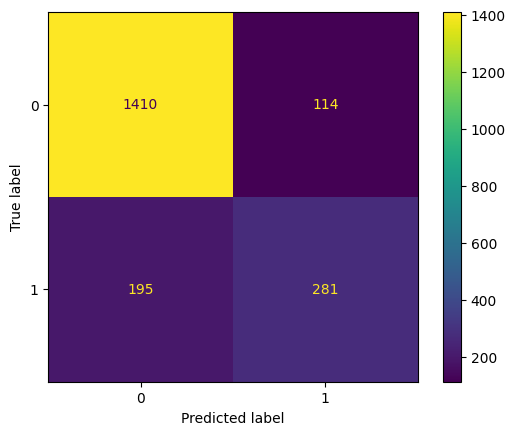

In [ ]:
best_=grid.best_estimator_
best_.fit(X_train, y_train)

y_pred = best_.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_.classes_)
disp.plot()
plt.show()